# HW05 – Predicting a Burglary and finding the best model with cost benefit analysis

### By Wasim Raja Mondal 

### 1. Create a Jupyter Notebook.

In [1]:
!pwd #created a notebook and working inside the directory HW05

/Users/wasim/Desktop/HW05


### 2. Import Libraries

In [2]:
!pip install numpy #installing numpy
!pip install pandas #installing pandas
!pip install matplotlib #installing matplotlib
!pip install seaborn #installing seaborn
!pip install statsmodels #installing statmodel
!pip install scikit-learn #installing scikit learn
import numpy as np  #importing numpy
import pandas as pd #importing pandas
import seaborn as sns #importing seaborn
import pandas as pd #importing pandas
import statsmodels  #importing statmodels
import statsmodels.api as sm
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',500) #allows for up to 500 columns to be displayed when viewing a dataframe
plt.style.use("seaborn-v0_8-whitegrid") ##a style that can be used for plots
import datetime as dt #importing datetime


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### 3. Import Data 

In [3]:
df_all = pd.read_csv('data/CantonPoliceDept_HW05.csv', index_col=None, header=0)
df_canton_new = pd.read_csv('data/CantonPoliceDept_HW05_week49.csv', index_col=None, header=0)
display(df_all.head())
df_canton_new.head()

,Index,Subzone,YEAR_WEEK,SUB_YEAR_WEEK,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,ActualBurg,BurgStatus,BurgStatus2,call_ALL_target,call_Burglary_target,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire),SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita
0,0,ZONE1A,2009_1,2009_1_ZONE1A,182,7,14,0,21,49,21,21,196,14,56,14,0,7,14,0,35,0,7,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.196943e+07,77,2866,0.481158,0.518842,1097,0.967183,0.830447,0.058341,2763,0.264206,0.020992,0.000000,0.031849,0.027506,0.735794,905,0.955801,0.131492,0.171271,0.181215,0.028729,33,27,40,25994,31089.00000,43746,27679,16862
1,1,ZONE1B,2009_1,2009_1_ZONE1B,144,9,18,0,9,63,9,18,153,18,36,0,0,0,0,0,0,0,27,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.330865e+07,68,3417,0.575066,0.424934,2025,0.984198,0.680988,0.225185,3295,0.301062,0.008801,0.004552,0.181184,0.040668,0.698938,1285,1.000000,0.062257,0.178210,0.021790,0.013230,37,38,34,52050,47114.00000,81316,55827,22271
2,2,ZONE1C,2009_1,2009_1_ZONE1C,230,30,10,0,10,80,10,20,260,10,40,20,0,10,0,0,30,0,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.501904e+06,30,626,0.322684,0.677316,317,1.000000,0.807571,0.164038,606,0.145215,0.044554,0.000000,0.023102,0.000000,0.854785,229,1.000000,0.296943,0.056769,0.165939,0.021834,45,37,46,22150,65078.29167,18068,34792,14181
3,3,ZONE1D,2009_1,2009_1_ZONE1D,189,0,18,9,27,63,0,27,189,9,27,18,9,9,18,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.306158e+08,182,4522,0.507519,0.492481,2366,0.988588,0.883770,0

,Index,Subzone,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire),SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita
0,0,ZONE1A,0,0,0,0,0,0,0,0,154,0,21,0,0,0,0,0,21,0,0,0,22,6,2,1,6,0,5,1,0,0,0,0,0,0,0,0,0,0,0,21,0,0,5,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,3,1,1,8,3,0,0,1,0,0,1,0,0,0,0,0,5,0,0,0,0,0,0,0,0,1,6,0,0,2,2,0,0,0,0,0,0,2.196943e+07,77,2866,0.481158,0.518842,1097,0.967183,0.830447,0.058341,2763,0.264206,0.020992,0.000000,0.031849,0.027506,0.735794,905,0.955801,0.131492,0.171271,0.181215,0.028729,33,27,40,25994,31089.00000,43746,27679,16862
1,1,ZONE1B,0,0,0,0,0,0,0,0,261,9,54,0,9,9,9,0,9,0,9,0,29,6,1,5,9,4,4,3,0,0,0,0,0,0,0,0,0,0,0,32,0,1,4,1,1,11,0,0,0,1,1,1,0,2,0,0,0,0,7,0,1,1,8,0,0,1,0,2,1,0,0,0,0,0,4,0,0,0,0,0,0,0,0,4,2,0,0,3,7,0,0,0,0,0,0,2.330865e+07,68,3417,0.575066,0.424934,2025,0.984198,0.680988,0.225185,3295,0.301062,0.008801,0.004552,0.181184,0.040668,0.698938,1285,1.000000,0.062257,0.178210,0.021790,0.013230,37,38,34,52050,47114.00000,81316,55827,22271
2,2,ZONE1C,0,0,0,0,0,0,0,0,300,0,100,10,0,0,10,0,50,0,10,0,30,2,9,2,3,3,6,4,0,0,0,0,0,0,0,0,0,0,0,29,0,1,3,0,1,2,0,1,1,1,1,0,0,0,1,0,0,0,11,1,0,5,1,2,0,0,4,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,2,10,0,0,5,2,0,0,0,0,0,0,6.501904e+06,30,626,0.322684,0.677316,317,1.000000,0.807571,0.164038,606,0.145215,0.044554,0.000000,0.023102,0.000000,0.854785,229,1.000000,0.296943,0.056769,0.165939,0.021834,45,37,46,22150,65078.29167,18068,34792,14181
3,3,ZONE1D,0,0,0,0,0,0,0,0,333,0,54,18,27,0,9,0,9,0,0,9,37,5,2,5,5,6,5,9,0,0,0,0,0,0,0,0,0,0,0,37,0,1,9,0,0,7,0,0,0,0,0,0,0,3,2,0,0,1,6,1,1,6,2,1,1,1,2,0,1,0,0,0,0,0,9,0,0,0,0,0,0,0,0,9,4,0,0,3,4,0,0,0,0,0,0,1.306158e+08,182,4522,0.507519,0.492481,2366,0.988588,0.883770,0.087489,4358,0.267324,0.011014,0.006884,0.109224,0.028683,0.732676,1657,1.000000,0.042245,0.166566,0.064575,0.050694,31,28,32,33225,35873.00000,32084,44433,20857
4,4,ZONE2A,0,0,0,0,0,0,0,0,132,0,44,4,4,4,0,0,16,0,4,0,33,8,3,2,3,7,6,4,0,0,0,

## 4. Create the datasets

* Using the df_all dataframe, create the X and y datasets.

In [4]:
y = df_all["BurgStatus"]
print(y.value_counts())
display(round(y.value_counts(normalize=True), 3))

BurgStatus
0    7576
1    4269
Name: count, dtype: int64


BurgStatus
0    0.64
1    0.36
Name: proportion, dtype: float64

In [5]:
X=df_all.drop(['BurgStatus'], axis=1)
X.columns

Index(['Index', 'Subzone', 'YEAR_WEEK', 'SUB_YEAR_WEEK', 'All_comp',
       'FalseAlarm_comp', 'Arrest_comp', 'Cleared_comp', 'NoContact_comp',
       'NoReport_comp',
       ...
       'Households_SSI', 'Households_publicassistanceincome',
       'MedianAge_Total', 'MedianAge_Male', 'MedianAge_Female',
       'HouseholdIncome_Median', 'HouseholdIncome_Median_25to44',
       'HouseholdIncome_Median_65andover', 'HouseholdIncome_Median_45to64',
       'Income_PerCapita'],
      dtype='object', length=133)

In [6]:
X=X.drop(['BurgStatus2', 'ActualBurg', 'YEAR_WEEK', 'SUB_YEAR_WEEK'], axis=1)
X.head()

,Index,Subzone,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,call_ALL_target,call_Burglary_target,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire),SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita
0,0,ZONE1A,182,7,14,0,21,49,21,21,196,14,56,14,0,7,14,0,35,0,7,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.196943e+07,77,2866,0.481158,0.518842,1097,0.967183,0.830447,0.058341,2763,0.264206,0.020992,0.000000,0.031849,0.027506,0.735794,905,0.955801,0.131492,0.171271,0.181215,0.028729,33,27,40,25994,31089.00000,43746,27679,16862
1,1,ZONE1B,144,9,18,0,9,63,9,18,153,18,36,0,0,0,0,0,0,0,27,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.330865e+07,68,3417,0.575066,0.424934,2025,0.984198,0.680988,0.225185,3295,0.301062,0.008801,0.004552,0.181184,0.040668,0.698938,1285,1.000000,0.062257,0.178210,0.021790,0.013230,37,38,34,52050,47114.00000,81316,55827,22271
2,2,ZONE1C,230,30,10,0,10,80,10,20,260,10,40,20,0,10,0,0,30,0,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.501904e+06,30,626,0.322684,0.677316,317,1.000000,0.807571,0.164038,606,0.145215,0.044554,0.000000,0.023102,0.000000,0.854785,229,1.000000,0.296943,0.056769,0.165939,0.021834,45,37,46,22150,65078.29167,18068,34792,14181
3,3,ZONE1D,189,0,18,9,27,63,0,27,189,9,27,18,9,9,18,0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.306158e+08,182,4522,0.507519,0.492481,2366,0.988588,0.883770,0.087489,4358,0.267324,0.011014,0.006884,0.109224,0.028683,0.732676,1657,1.000000,0.042245,0.166566,0.064575,0.050694,31,28,32,33225,35873.00000,32084,44433,20857
4,4,

In [7]:
X = pd.get_dummies(X, columns=["Subzone"], drop_first=True)
X.head()

,Index,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,call_ALL_target,call_Burglary_target,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire),SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita,Subzone_ZONE1B,Subzone_ZONE1C,Subzone_ZONE1D,Subzone_ZONE2A,Subzone_ZONE2B,Subzone_ZONE2D,Subzone_ZONE3B,Subzone_ZONE3C,Subzone_ZONE3D,Subzone_ZONE3E,Subzone_ZONE4B,Subzone_ZONE4C,Subzone_ZONE5A,Subzone_ZONE5B,Subzone_ZONE5C,Subzone_ZONE5D,Subzone_ZONE6A,Subzone_ZONE6B,Subzone_ZONE6C,Subzone_ZONE7B,Subzone_ZONE7C,Subzone_ZONE7D
0,0,182,7,14,0,21,49,21,21,196,14,56,14,0,7,14,0,35,0,7,14,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.196943e+07,77,2866,0.481158,0.518842,1097,0.967183,0.830447,0.058341,2763,0.264206,0.020992,0.000000,0.031849,0.027506,0.735794,905,0.955801,0.131492,0.171271,0.181215,0.028729,33,27,40,25994,31089.00000,43746,27679,16862,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1,144,9,18,0,9,63,9,18,153,18,36,0,0,0,0,0,0,0,27,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.330865e+07,68,3417,0.575066,0.424934,2025,0.984198,0.680988,0.225185,3295,0.301062,0.008801,0.004552,0.181184,0.040668,0.698938,1285,1.000000,0.062257,0.178210,0.021790,0.013230,37,38,34,52050,47114.00000,81316,55827,22271,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2,230,30,10,0,10,80,10,20,260,10,40,20,0,10,0,0,30,0,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.501904e+06,30,626,0.322684,0.677316,317,1.000000,0.807571,0.164038,606,0.145215,0.044554,0.000000,0.0

### 4.2 Create the training and test datasets

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)
display(y_train.head())
X_train.head()

5163    0
2865    0
4341    0
6387    0
2291    1
Name: BurgStatus, dtype: int64

,Index,All_comp,FalseAlarm_comp,Arrest_comp,Cleared_comp,NoContact_comp,NoReport_comp,Resolved_comp,Filed_comp,Calls_comp,BurgAlarm_comp,Suspicious_comp,Shots_comp,Intox_comp,Drugs_comp,Assault_comp,Armed_comp,Disturb_comp,Fireworks_comp,Noise_comp,Stalking_comp,call_ALL_target,call_Burglary_target,call_ALL,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,call_Armed subject,call_Assault,call_Burglar alarm,call_Burglary,call_Disturbance,call_Domestic,call_FW FIREWORKS,call_Fight,call_Loitering,call_Message delivery,call_Noise complaint,call_Possible drugs present,call_Prowler,call_Public Intoxication,call_Shots fired,call_Special residence patrol,call_Special watch,call_Stalking,call_Suspicious activity,call_Trespassing,call_Vandalism,call_Welfare check,disp_15-ARREST,disp_66-CANCEL,disp_9-VERBAL,disp_ADV-ADVICE GIVEN,disp_AST-ASSIST,disp_CI-CITY CITATION,disp_CLR-CLEARED BY DISPATCH,disp_CM-CIVIL MATTER,disp_COMP,disp_DISR,disp_Disregard,disp_Domestic Violence Report,disp_FA-FALSE ALARM,disp_FD-FOUNDED ALARM,disp_FI-FIELD INTERVIEW,disp_Gone on Arrival,disp_IRT Report,disp_K9 Report,disp_MC-STATE MISD CITATION,disp_MDT-BOLO'D MDT,disp_MSG-MESSAGE DELIVERED,disp_N25-NO CONTACT,disp_NR-NO REPORT,disp_Other,disp_PR-PROPERTY RETURNED,disp_RES-RESOLVED,disp_RF-REPORT FILED,disp_Runaway juvenile (entered NCIC),disp_SAT-SETTLED AMONG SELVES,disp_TES-TEST,disp_TI -TOW IN,disp_Truancy,disp_VA Hospital Alarm (Fire),SqFootage,HousingUnits,Population,Population_Male,Population_Female,Worked,Workers who travel to work,Drove alone to Work,Carpooled to Work,Population_3andover,Enrolled in school,"Enrolled in nursery school, preschool",Enrolled in kindergarten,"Enrolled in college, undergraduate years",Graduate or professional school,Not enrolled in school,Households_earnings,Households_wageorsalaryincome,Households_selfemploymentincome,Households_interest_dividends,Households_SSI,Households_publicassistanceincome,MedianAge_Total,MedianAge_Male,MedianAge_Female,HouseholdIncome_Median,HouseholdIncome_Median_25to44,HouseholdIncome_Median_65andover,HouseholdIncome_Median_45to64,Income_PerCapita,Subzone_ZONE1B,Subzone_ZONE1C,Subzone_ZONE1D,Subzone_ZONE2A,Subzone_ZONE2B,Subzone_ZONE2D,Subzone_ZONE3B,Subzone_ZONE3C,Subzone_ZONE3D,Subzone_ZONE3E,Subzone_ZONE4B,Subzone_ZONE4C,Subzone_ZONE5A,Subzone_ZONE5B,Subzone_ZONE5C,Subzone_ZONE5D,Subzone_ZONE6A,Subzone_ZONE6B,Subzone_ZONE6C,Subzone_ZONE7B,Subzone_ZONE7C,Subzone_ZONE7D
5163,5163,11,0,0,0,1,2,4,1,11,0,1,0,3,0,0,0,2,0,1,0,21,0,10,0,4,2,0,2,1,2,0,0,0,0,0,11,0,0,0,0,0,0,0,0,0,0,1,2,0,0,0,1,1,0,0,3,0,0,0,0,1,1,1,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,0,0,4,1,0,0,0,0,0,0,1.605488e+08,339,16874,0.485540,0.514460,8880,0.961036,0.840428,0.105968,16408,0.317101,0.013286,0.031021,0.066248,0.016699,0.682899,5413,0.962867,0.111768,0.143174,0.036024,0.015518,35,33,37,82487,82696.0,60411,84617,33754,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
2865,2865,110,5,15,5,10,10,20,15,115,5,20,0,0,0,0,5,25,0,15,0,16,1,20,3,2,0,3,3,1,4,0,0,0,0,0,0,16,0,0,0,0,0,1,0,1,1,2,4,0,0,1,0,1,0,0,0,0,0,1,0,0,2,1,1,0,0,0,1,0,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,2,2,0,0,4,3,0,0,0,0,0,0,1.400857e+07,48,2554,0.384495,0.615505,1502,0.991345,0.970040,0.010652,2409,0.335409,0.007887,0.000000,0.258198,0.003736,0.664591,860,1.000000,0.046512,0.040698,0.011628,0.052326,24,30,23,34549,46625.0,15750,38017,16614,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4341,4341,30,16,0,0,2,10,0,0,30,2,8,0,0,0,0,0,0,0,2,0,14,0,15,1,3,2,1,1,3,4,15,0,0,0,0,0,0,0,0,0,0,0,0,0,8,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,8,0,0,0,0,0,0,0,0,1,5,0,0,0,0,0,0,0,0,0,0,1.939506e+08,393,14516,0.494902,0.505098,6997,0.943976,0.864799,0.066028,14188,0.276078,0.012475,0.007189

### 4.3 Create the scaled versions of X_train and X_test datasets

In [9]:
from sklearn import preprocessing

sc = preprocessing.StandardScaler()
sc.fit(X_train)
X_train_sc = sc.transform(X_train)
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)


X_test_sc = sc.transform(X_test)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

## 5. Classification using Random Forest

**Using Random Forest create a model using the raw data**

In [10]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.model_selection import cross_val_score

In [11]:
def modeltraintest(vartrain, vartest, Y_train, Y_test, model):

    # 1) Fit the model with training data
    model.fit(vartrain, Y_train)

    # 2) Predict using test data
    model_pred = model.predict(vartest)
    model_prob = model.predict_proba(vartest)

    # 3) Accuracy
    score = model.score(vartest, Y_test)

    print('XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX')
    print(round(score, 6))
    print("")

    # 4) Confusion Matrix
    print('XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX')
    print(confusion_matrix(Y_test, model_pred))
    print("")

    # 5) Classification Report
    print('XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX')
    print(classification_report(Y_test, model_pred))
    print('')

    # 6) ROC + AUC
    print('XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX')
    print('')

    y_pred_prob = model.predict_proba(vartest)[:, 1]

    fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)
    roc_auc = roc_auc_score(Y_test, y_pred_prob)

    print("ROC AUC Score:", roc_auc)

In [12]:
def shorttraintest(vartrain, vartest, Y_train, Y_test, model):

    # Fit the model
    model.fit(vartrain, Y_train)

    # Predict
    model_pred = model.predict(vartest)
    model_prob = model.predict_proba(vartest)

    print('Confusion Matrix:')
    print(confusion_matrix(Y_test, model_pred))
    print("")

    # Accuracy
    score = model.score(vartest, Y_test)
    score_format = 'Accuracy Score: {0:.4f}'.format(score)
    print(score_format)

    # Recall
    recall = recall_score(Y_test, model_pred)
    recall_format = 'Recall Score: {0:.4f}'.format(recall)
    print(recall_format)

    # Precision
    precision = precision_score(Y_test, model_pred)
    precision_format = 'Precision Score: {0:.4f}'.format(precision)
    print(precision_format)

    # ROC Curve
    y_pred_prob = model.predict_proba(vartest)[:, 1]

    fpr, tpr, thresholds = roc_curve(Y_test, y_pred_prob)
    roc_auc = roc_auc_score(Y_test, y_pred_prob)

    roc_auc_format = 'ROC AUC Score: {0:.4f}'.format(roc_auc)
    print(roc_auc_format)
    print('')

In [13]:


vartrain = X_train
vartest = X_test

model = RandomForestClassifier(random_state=21)

modeltraintest(vartrain, vartest, y_train, y_test, model)

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.815982

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[1967  272]
 [ 382  933]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      2239
           1       0.77      0.71      0.74      1315

    accuracy                           0.82      3554
   macro avg       0.81      0.79      0.80      3554
weighted avg       0.81      0.82      0.81      3554


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.8864411903059657


In [14]:


vartrain = X_train
vartest = X_test

model = RandomForestClassifier(random_state=21)

shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[1967  272]
 [ 382  933]]

Accuracy Score: 0.8160
Recall Score: 0.7095
Precision Score: 0.7743
ROC AUC Score: 0.8864



**With no set_max_depth, it can overfit on the training data**

In [15]:

vartrain = X_train
vartest = X_test

model = RandomForestClassifier(random_state=21)

shorttraintest(vartrain, vartrain, y_train, y_train, model)

Confusion Matrix:
[[5337    0]
 [   0 2954]]

Accuracy Score: 1.0000
Recall Score: 1.0000
Precision Score: 1.0000
ROC AUC Score: 1.0000



**We will maually set parameter for this**

## 5.2 Fine-tune the model to find the OPTIMAL model (Based on Accuracy)

iteration 6 done. Accuracy = 0.8081035453010692
iteration 8 done. Accuracy = 0.8134496342149691
iteration 10 done. Accuracy = 0.8111986494091165
iteration 12 done. Accuracy = 0.8126055149127743
iteration 14 done. Accuracy = 0.8179516038266742
iteration 16 done. Accuracy = 0.8185143500281373
iteration 17 done. Accuracy = 0.8159819921215532
iteration 18 done. Accuracy = 0.8134496342149691
iteration 19 done. Accuracy = 0.8187957231288688
iteration 20 done. Accuracy = 0.8140123804164322
iteration 21 done. Accuracy = 0.8193584693303321
iteration 22 done. Accuracy = 0.8162633652222847
iteration 23 done. Accuracy = 0.8151378728193585
iteration 30 done. Accuracy = 0.8168261114237478


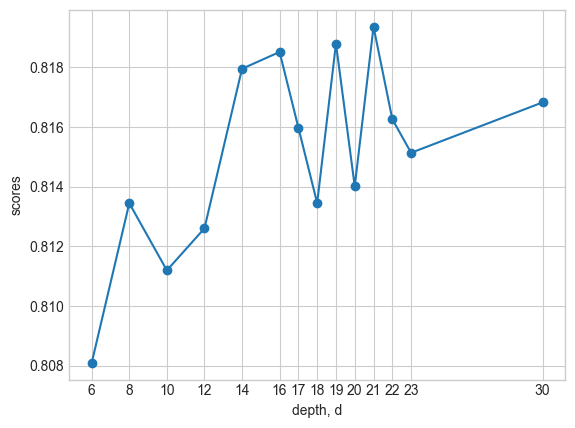

In [16]:
# depth = range(6, 25)

#chose depth
depth = [6, 8, 10, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 30]

# Creates an empty list
scores = []

for d in depth:
    classifier = RandomForestClassifier(max_depth=d, random_state=21)
    classifier = classifier.fit(X_train, y_train)

    score = classifier.score(X_test, y_test)
    scores.append(classifier.score(X_test, y_test))

    print("iteration {} done. Accuracy = ".format(d) + str(score))

plt.plot(depth, scores, '-o')
plt.xlabel('depth, d')
plt.ylabel('scores')
plt.xticks(depth)
plt.show()

*We are considering max depth 21 because it is giving maximum accuracy*

In [17]:

vartrain = X_train
vartest = X_test

model = RandomForestClassifier(max_depth=21, random_state=21)

shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[1972  267]
 [ 375  940]]

Accuracy Score: 0.8194
Recall Score: 0.7148
Precision Score: 0.7788
ROC AUC Score: 0.8867



**Lets see how much it overfits the training data**

In [18]:

vartrain = X_train
vartest = X_test

model = RandomForestClassifier(max_depth=21, random_state=21)

shorttraintest(vartrain, vartrain, y_train, y_train, model)

Confusion Matrix:
[[5337    0]
 [   3 2951]]

Accuracy Score: 0.9996
Recall Score: 0.9990
Precision Score: 1.0000
ROC AUC Score: 1.0000



iteration 1 done. Accuracy = 0.7726505346088914
iteration 2 done. Accuracy = 0.7810917276308385
iteration 3 done. Accuracy = 0.7945976364659538
iteration 4 done. Accuracy = 0.7962858750703433
iteration 5 done. Accuracy = 0.8047270680922903
iteration 6 done. Accuracy = 0.8111986494091165
iteration 7 done. Accuracy = 0.8103545301069218
iteration 8 done. Accuracy = 0.8064153066966798
iteration 9 done. Accuracy = 0.8100731570061902
iteration 10 done. Accuracy = 0.8151378728193585
iteration 11 done. Accuracy = 0.8187957231288688
iteration 12 done. Accuracy = 0.8193584693303321
iteration 13 done. Accuracy = 0.8142937535171637
iteration 14 done. Accuracy = 0.8173888576252111
iteration 15 done. Accuracy = 0.8179516038266742
iteration 16 done. Accuracy = 0.8173888576252111
iteration 17 done. Accuracy = 0.8173888576252111
iteration 18 done. Accuracy = 0.8171074845244795
iteration 19 done. Accuracy = 0.8179516038266742
iteration 20 done. Accuracy = 0.8182329769274057
iteration 21 done. Accuracy =

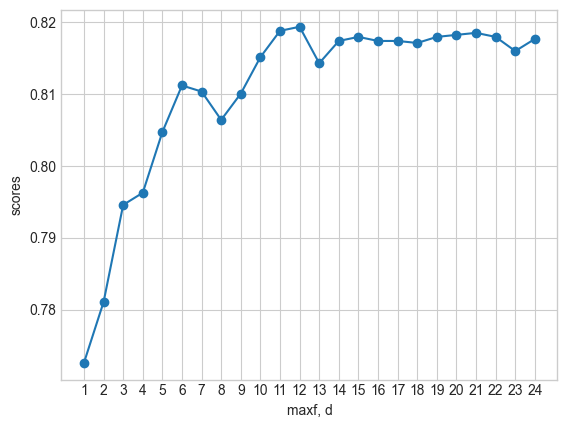

In [19]:
figsize = (20, 5)

maxf = range(1, 25)
scores = []

for d in maxf:
    classifier = RandomForestClassifier(
        max_depth=21,
        max_features=d,
        random_state=21
    )

    classifier = classifier.fit(X_train, y_train)

    score = classifier.score(X_test, y_test)
    scores.append(classifier.score(X_test, y_test))

    print("iteration {} done. Accuracy = ".format(d) + str(score))

plt.plot(maxf, scores, '-o')
plt.xlabel('maxf, d')
plt.ylabel('scores')
plt.xticks(maxf)
plt.show()

In [20]:
vartrain = X_train
vartest = X_test

model = RandomForestClassifier(max_depth=21,  max_features=12, random_state=21)

shorttraintest(vartrain, vartrain, y_train, y_train, model)

Confusion Matrix:
[[5337    0]
 [   3 2951]]

Accuracy Score: 0.9996
Recall Score: 0.9990
Precision Score: 1.0000
ROC AUC Score: 1.0000



iteration 1 done. Accuracy = 0.7234102419808667
iteration 20 done. Accuracy = 0.8036015756893641
iteration 50 done. Accuracy = 0.8126055149127743
iteration 100 done. Accuracy = 0.8162633652222847
iteration 150 done. Accuracy = 0.8196398424310636
iteration 500 done. Accuracy = 0.8176702307259426


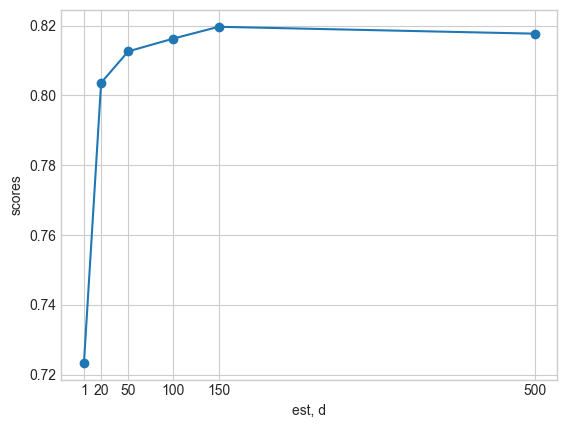

In [21]:
figsize = (20, 5)

est = [1, 20, 50, 100, 150, 500]
scores = []

for d in est:
    classifier = RandomForestClassifier(
        max_depth=22,
        max_features=12,
        n_estimators=d,
        random_state=21
    )

    classifier = classifier.fit(X_train, y_train)

    score = classifier.score(X_test, y_test)
    scores.append(classifier.score(X_test, y_test))

    print("iteration {} done. Accuracy = ".format(d) + str(score))

plt.plot(est, scores, '-o')
plt.xlabel('est, d')
plt.ylabel('scores')
plt.xticks(est)
plt.show()

In [22]:
vartrain = X_train
vartest = X_test

model = RandomForestClassifier(max_depth=21,  max_features=12, n_estimators=50, random_state=21)

shorttraintest(vartrain, vartest, y_train, y_test, model)

Confusion Matrix:
[[1958  281]
 [ 381  934]]

Accuracy Score: 0.8137
Recall Score: 0.7103
Precision Score: 0.7687
ROC AUC Score: 0.8838



**Is it still overfit?**

In [23]:
vartrain = X_train
vartest = X_test

model = RandomForestClassifier(max_depth=21,  max_features=12, n_estimators=50, random_state=21)

shorttraintest(vartrain, vartrain, y_train, y_train, model)

Confusion Matrix:
[[5337    0]
 [  13 2941]]

Accuracy Score: 0.9984
Recall Score: 0.9956
Precision Score: 1.0000
ROC AUC Score: 1.0000



## 5.3 Fine-tune the model to find the DECISION model

In [24]:

cw = [
    None,
    'balanced',
    {0: 1, 1: 2},
    {0: 1, 1: 3},
    {0: 1, 1: 5},
    {0: 1, 1: 10},
    {0: 1, 1: 20},
    {0: 1, 1: 25},
    {0: 1, 1: 30},
    {0: 1, 1: 50},
    {0: 1, 1: 100}
]

vartrain = X_train
vartest = X_test

for w in cw:
    print('-----------------------')

    vartitle = "Model with Class Weight: " + str(w)
    varcw = w

    model = RandomForestClassifier(
        max_depth=22,
        max_features=12,
        n_estimators=20,
        class_weight=varcw
    )

    print(vartitle)
    print('')

    shorttraintest(vartrain, vartest, y_train, y_test, model)

print('-----------------------')

-----------------------
Model with Class Weight: None

Confusion Matrix:
[[1972  267]
 [ 416  899]]

Accuracy Score: 0.8078
Recall Score: 0.6837
Precision Score: 0.7710
ROC AUC Score: 0.8770

-----------------------
Model with Class Weight: balanced

Confusion Matrix:
[[1997  242]
 [ 458  857]]

Accuracy Score: 0.8030
Recall Score: 0.6517
Precision Score: 0.7798
ROC AUC Score: 0.8734

-----------------------
Model with Class Weight: {0: 1, 1: 2}

Confusion Matrix:
[[1983  256]
 [ 426  889]]

Accuracy Score: 0.8081
Recall Score: 0.6760
Precision Score: 0.7764
ROC AUC Score: 0.8755

-----------------------
Model with Class Weight: {0: 1, 1: 3}

Confusion Matrix:
[[1988  251]
 [ 414  901]]

Accuracy Score: 0.8129
Recall Score: 0.6852
Precision Score: 0.7821
ROC AUC Score: 0.8744

-----------------------
Model with Class Weight: {0: 1, 1: 5}

Confusion Matrix:
[[1975  264]
 [ 408  907]]

Accuracy Score: 0.8109
Recall Score: 0.6897
Precision Score: 0.7746
ROC AUC Score: 0.8787

------------

In [25]:
#This is best RandomForestClassifier
vartrain = X_train
vartest = X_test

model = RandomForestClassifier(
    max_depth=22,
    max_features=12,
    n_estimators=20,
    class_weight={0:1, 1:10}
)

modeltraintest(vartrain, vartest, y_train, y_test, model)

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.818796

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[1939  300]
 [ 344  971]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      2239
           1       0.76      0.74      0.75      1315

    accuracy                           0.82      3554
   macro avg       0.81      0.80      0.80      3554
weighted avg       0.82      0.82      0.82      3554


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.871453510784452


## 5.4 Comments throughout Section 5 – and Summary Table

## Random Forest Model Selection

The Random Forest model parameters were selected based on a systematic
evaluation of model performance using different optimization objectives.

### Accuracy Optimization

To maximize overall predictive accuracy, several combinations of Random
Forest hyperparameters were evaluated. The final model configuration was:

- **max_depth = 22**
- **max_features = 12**
- **n_estimators = 20**

These parameters were chosen because they produced the highest accuracy
(score) on the testing dataset. Increasing the tree depth allowed the model
to capture more complex relationships between subzone characteristics and
burglary occurrences, while limiting the number of features considered at
each split helped reduce overfitting and improved generalization. The use
of 20 estimators provided a stable ensemble without unnecessary model
complexity or computational cost.

### Decision-Oriented Optimization

While accuracy is useful for general prediction performance, operational
decision-making for the Canton Police Department requires balancing:

- **Precision** — avoiding unnecessary officer deployment (false positives)
- **Recall** — minimizing missed burglaries (false negatives)

Therefore, class weights were tuned separately to improve precision and
recall performance. Adjusting the `class_weight` parameter allowed the model
to place greater importance on correctly identifying burglary events,
which is critical because missed burglaries incur higher operational costs.

### Rationale for Final Model Choice

Two optimization perspectives were considered:

1. **Accuracy-based model**
   - Optimized using score (overall correctness).
   - Ensures strong general predictive performance.

2. **Decision-based model**
   - Optimized using precision and recall.
   - Better aligned with real-world policing costs and resource allocation.

By combining accuracy optimization with decision-focused class weighting,
the final Random Forest model provides both strong predictive capability
and practical operational value for burglary prevention planning.

This approach supports data-driven decision making by balancing statistical
performance with real-world consequences of prediction errors.

# 6. Cost Benefit Analysis

*Logistic regression*

*Accuracy model*

iteration 0.001 done. Accuracy = 0.7746201463140123
iteration 0.01 done. Accuracy = 0.7929093978615644
iteration 0.1 done. Accuracy = 0.7948790095666854
iteration 1 done. Accuracy = 0.7957231288688801
iteration 10 done. Accuracy = 0.7962858750703433
iteration 100 done. Accuracy = 0.7962858750703433
iteration 1000 done. Accuracy = 0.7962858750703433


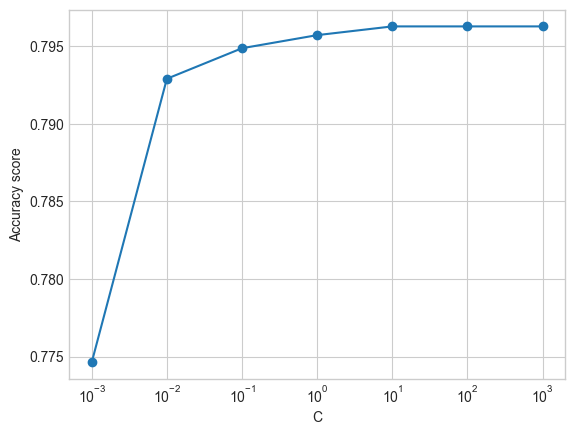

In [26]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

# Store scores
scores = []

for c in C_values:
    classifier = LogisticRegression(
        C=c,
        max_iter=1000,
        random_state=21
    )

    classifier.fit(X_train_sc, y_train)

    score = classifier.score(X_test_sc, y_test)
    scores.append(score)

    print("iteration {} done. Accuracy = {}".format(c, score))

plt.plot(C_values, scores, '-o')
plt.xlabel('C')
plt.ylabel('Accuracy score')
plt.xscale('log')  
plt.show()

In [27]:

vartrain = X_train_sc
vartest = X_test_sc

model = LogisticRegression(
        C=10,
        max_iter=1000,
        random_state=21
    )

modeltraintest(vartrain, vartest, y_train, y_test, model)

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.796286

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[2033  206]
 [ 518  797]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.80      0.91      0.85      2239
           1       0.79      0.61      0.69      1315

    accuracy                           0.80      3554
   macro avg       0.80      0.76      0.77      3554
weighted avg       0.80      0.80      0.79      3554


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.877178669863821


solver lbfgs done. Accuracy = 0.7962858750703433
solver liblinear done. Accuracy = 0.7957231288688801
solver newton-cg done. Accuracy = 0.7957231288688801
solver sag done. Accuracy = 0.7960045019696117
solver saga done. Accuracy = 0.7954417557681486


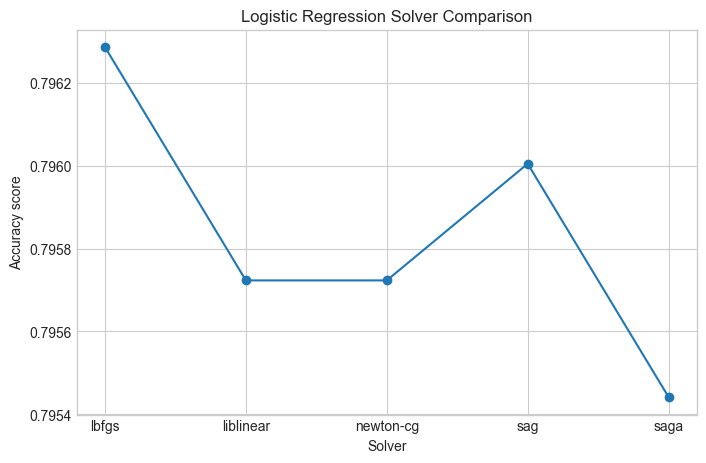

In [28]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Solvers to test
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

scores = []

for s in solvers:

    classifier = LogisticRegression(
        C=10,
        solver=s,
        max_iter=1000,
        random_state=21
    )

    classifier.fit(X_train_sc, y_train)

    score = classifier.score(X_test_sc, y_test)
    scores.append(score)

    print("solver {} done. Accuracy = {}".format(s, score))

# Plot
plt.figure(figsize=(8,5))
plt.plot(solvers, scores, '-o')
plt.xlabel('Solver')
plt.ylabel('Accuracy score')
plt.title('Logistic Regression Solver Comparison')
plt.grid(True)
plt.show()

In [29]:
vartrain = X_train_sc
vartest = X_test_sc

model = LogisticRegression(
        C=10,
        solver = 'lbfgs',
        max_iter=1000,
        random_state=21
    )

modeltraintest(vartrain, vartest, y_train, y_test, model)

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.796286

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[2033  206]
 [ 518  797]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.80      0.91      0.85      2239
           1       0.79      0.61      0.69      1315

    accuracy                           0.80      3554
   macro avg       0.80      0.76      0.77      3554
weighted avg       0.80      0.80      0.79      3554


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.877178669863821


class_weight None done. Accuracy = 0.7963
class_weight balanced done. Accuracy = 0.8101
class_weight {0: 1, 1: 2} done. Accuracy = 0.8092
class_weight {0: 1, 1: 3} done. Accuracy = 0.7999
class_weight {0: 1, 1: 5} done. Accuracy = 0.7423
class_weight {0: 1, 1: 10} done. Accuracy = 0.6210
class_weight {0: 1, 1: 20} done. Accuracy = 0.5276

Best class_weight: balanced
Best Accuracy: 0.8101


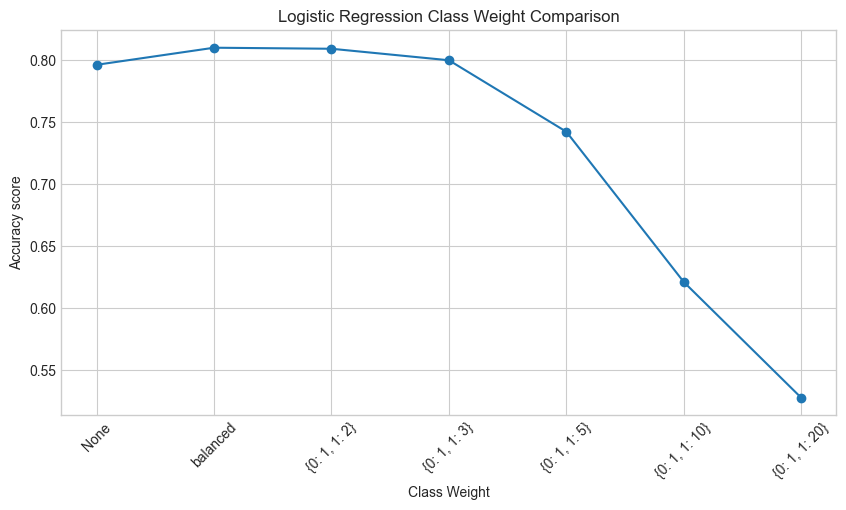

In [30]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import numpy as np

# Class weights to test
class_weights = [
    None,
    'balanced',
    {0:1, 1:2},
    {0:1, 1:3},
    {0:1, 1:5},
    {0:1, 1:10},
    {0:1, 1:20}
]

scores = []

for cw in class_weights:

    classifier = LogisticRegression(
        C=10,
        solver='lbfgs',
        class_weight=cw,
        max_iter=1000,
        random_state=21
    )

    classifier.fit(X_train_sc, y_train)

    score = classifier.score(X_test_sc, y_test)
    scores.append(score)

    print(f"class_weight {cw} done. Accuracy = {score:.4f}")

# Find best
best_index = np.argmax(scores)
best_weight = class_weights[best_index]
best_score = scores[best_index]

print("\n====================================")
print(f"Best class_weight: {best_weight}")
print(f"Best Accuracy: {best_score:.4f}")
print("====================================")

# Plot
labels = [str(cw) for cw in class_weights]

plt.figure(figsize=(10,5))
plt.plot(labels, scores, '-o')
plt.xlabel('Class Weight')
plt.ylabel('Accuracy score')
plt.title('Logistic Regression Class Weight Comparison')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [31]:
#best accurate Logistic regression model
vartrain = X_train_sc
vartest = X_test_sc

model = LogisticRegression(
        C=10,
        solver = 'lbfgs',
        class_weight='balanced',
        max_iter=1000,
        random_state=21
    )

modeltraintest(vartrain, vartest, y_train, y_test, model)

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.810073

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[1888  351]
 [ 324  991]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      2239
           1       0.74      0.75      0.75      1315

    accuracy                           0.81      3554
   macro avg       0.80      0.80      0.80      3554
weighted avg       0.81      0.81      0.81      3554


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.878962804212228


**Now, we are looking for best logistic decession model**

C=0.001 | Precision=0.7014 | Recall=0.7019 | F1=0.7016
C=0.01 | Precision=0.7341 | Recall=0.7308 | F1=0.7325
C=0.1 | Precision=0.7380 | Recall=0.7452 | F1=0.7416
C=1 | Precision=0.7377 | Recall=0.7529 | F1=0.7452
C=10 | Precision=0.7385 | Recall=0.7536 | F1=0.7460
C=100 | Precision=0.7381 | Recall=0.7544 | F1=0.7461
C=1000 | Precision=0.7381 | Recall=0.7544 | F1=0.7461

Best C based on Precision + Recall (F1): 100
Best F1: 0.7461451673561489


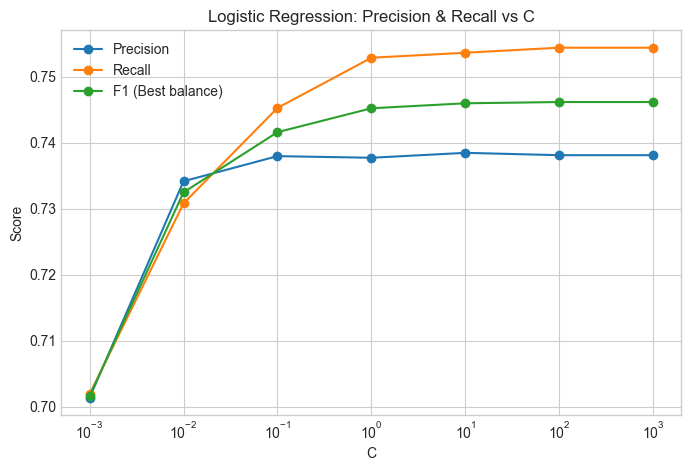

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

precision_scores = []
recall_scores = []
f1_scores = []

for c in C_values:

    classifier = LogisticRegression(
        C=c,
        solver='lbfgs',
        class_weight='balanced',  
        max_iter=1000,
        random_state=21
    )

    classifier.fit(X_train_sc, y_train)

    y_pred = classifier.predict(X_test_sc)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(
        f"C={c} | Precision={precision:.4f} "
        f"| Recall={recall:.4f} | F1={f1:.4f}"
    )

# ---------------- Best C ----------------
best_index = np.argmax(f1_scores)
print("\nBest C based on Precision + Recall (F1):", C_values[best_index])
print("Best F1:", f1_scores[best_index])

# ---------------- Plot ----------------
plt.figure(figsize=(8,5))

plt.plot(C_values, precision_scores, '-o', label='Precision')
plt.plot(C_values, recall_scores, '-o', label='Recall')
plt.plot(C_values, f1_scores, '-o', label='F1 (Best balance)')

plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Score')
plt.title('Logistic Regression: Precision & Recall vs C')
plt.legend()
plt.grid(True)
plt.show()

class_weight=None | Precision=0.7946 | Recall=0.6061 | F1=0.6877
class_weight=balanced | Precision=0.7381 | Recall=0.7544 | F1=0.7461
class_weight={0: 1, 1: 2} | Precision=0.7260 | Recall=0.7757 | F1=0.7500
class_weight={0: 1, 1: 3} | Precision=0.6826 | Recall=0.8555 | F1=0.7594
class_weight={0: 1, 1: 5} | Precision=0.6004 | Recall=0.9095 | F1=0.7233
class_weight={0: 1, 1: 10} | Precision=0.4932 | Recall=0.9650 | F1=0.6528
class_weight={0: 1, 1: 20} | Precision=0.4388 | Recall=0.9916 | F1=0.6084
class_weight={0: 1, 1: 30} | Precision=0.4267 | Recall=0.9939 | F1=0.5971

Best class_weight: {0: 1, 1: 3}
Best F1: 0.7593655079311509


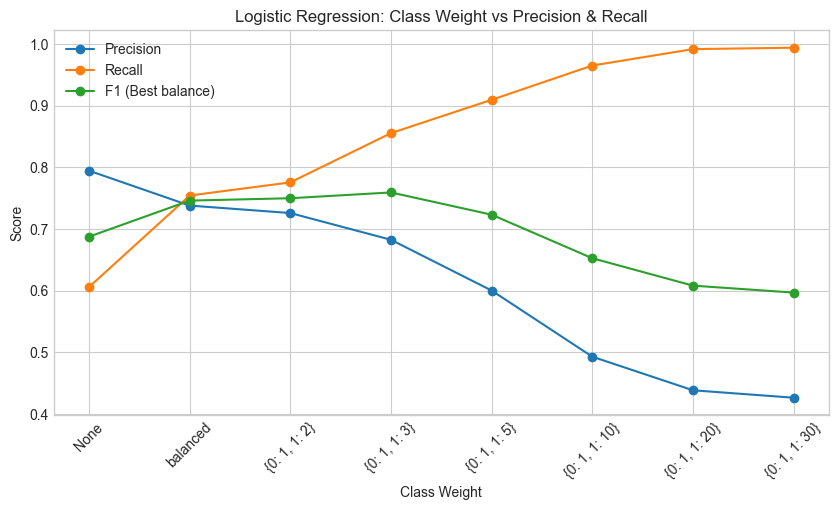

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Class weights to test
class_weights = [
    None,
    'balanced',
    {0:1, 1:2},
    {0:1, 1:3},
    {0:1, 1:5},
    {0:1, 1:10},
    {0:1, 1:20},
    {0:1, 1:30}
]

precision_scores = []
recall_scores = []
f1_scores = []

for cw in class_weights:

    classifier = LogisticRegression(
        C=100,
        solver='lbfgs',
        class_weight=cw,
        max_iter=1000,
        random_state=21
    )

    classifier.fit(X_train_sc, y_train)

    y_pred = classifier.predict(X_test_sc)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(
        f"class_weight={cw} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )

# ---------------- Best class weight ----------------
best_index = np.argmax(f1_scores)

print("\n====================================")
print("Best class_weight:", class_weights[best_index])
print("Best F1:", f1_scores[best_index])
print("====================================")

# ---------------- Plot ----------------
labels = [str(cw) for cw in class_weights]

plt.figure(figsize=(10,5))
plt.plot(labels, precision_scores, '-o', label='Precision')
plt.plot(labels, recall_scores, '-o', label='Recall')
plt.plot(labels, f1_scores, '-o', label='F1 (Best balance)')

plt.xlabel('Class Weight')
plt.ylabel('Score')
plt.title('Logistic Regression: Class Weight vs Precision & Recall')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [34]:
#best Decession Logistic regression model
vartrain = X_train_sc
vartest = X_test_sc

model = LogisticRegression(
        C=100,
        solver='lbfgs',
        class_weight={0: 1, 1: 3},
        max_iter=1000,
        random_state=21
    )

modeltraintest(vartrain, vartest, y_train, y_test, model)

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.799381

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[1716  523]
 [ 190 1125]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2239
           1       0.68      0.86      0.76      1315

    accuracy                           0.80      3554
   macro avg       0.79      0.81      0.79      3554
weighted avg       0.82      0.80      0.80      3554


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.8800136535695423


In [35]:
#Decession tree for best accuracy


iteration 1 done. Accuracy = 0.8168261114237478
iteration 2 done. Accuracy = 0.8168261114237478
iteration 3 done. Accuracy = 0.8269555430500845
iteration 4 done. Accuracy = 0.8258300506471581
iteration 5 done. Accuracy = 0.8238604389420371
iteration 6 done. Accuracy = 0.825267304445695
iteration 8 done. Accuracy = 0.8241418120427687
iteration 10 done. Accuracy = 0.8114800225098481
iteration 12 done. Accuracy = 0.8078221722003377
iteration 14 done. Accuracy = 0.7960045019696117
iteration 16 done. Accuracy = 0.7816544738323016
iteration 18 done. Accuracy = 0.76702307259426
iteration 20 done. Accuracy = 0.7653348339898706
iteration 22 done. Accuracy = 0.7658975801913337
iteration 25 done. Accuracy = 0.7571750140686551
iteration 30 done. Accuracy = 0.7532357906584131

Best max_depth: 3
Best Accuracy: 0.827


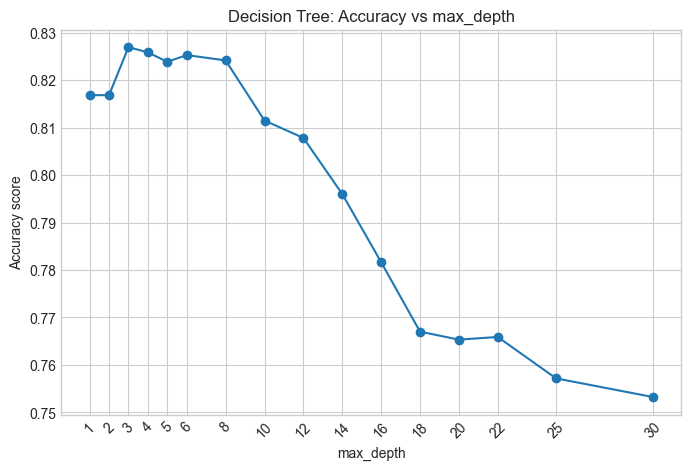

In [36]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

# Max depths to test
depth_values = [1, 2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 18, 20, 22, 25, 30]

# Store scores
scores = []

for d in depth_values:
    classifier = DecisionTreeClassifier(
        max_depth=d,
        random_state=21
    )

    classifier.fit(X_train, y_train)

    score = classifier.score(X_test, y_test)
    scores.append(score)

    print("iteration {} done. Accuracy = {}".format(d, score))

# Best depth
best_idx = int(np.argmax(scores))
best_depth = depth_values[best_idx]
best_score = scores[best_idx]

print("\n====================================")
print("Best max_depth:", best_depth)
print("Best Accuracy:", round(best_score, 4))
print("====================================")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(depth_values, scores, "-o")
plt.xlabel("max_depth")
plt.ylabel("Accuracy score")
plt.title("Decision Tree: Accuracy vs max_depth")
plt.xticks(depth_values, rotation=45)
plt.grid(True)
plt.show()

iteration 2 done. Accuracy = 0.8168261114237478
iteration 3 done. Accuracy = 0.8168261114237478
iteration 4 done. Accuracy = 0.8258300506471581
iteration 5 done. Accuracy = 0.8258300506471581
iteration 6 done. Accuracy = 0.8258300506471581
iteration 8 done. Accuracy = 0.8269555430500845
iteration 10 done. Accuracy = 0.8269555430500845
iteration 15 done. Accuracy = 0.8269555430500845
iteration 20 done. Accuracy = 0.8269555430500845
iteration 25 done. Accuracy = 0.8269555430500845
iteration 30 done. Accuracy = 0.8269555430500845
iteration 40 done. Accuracy = 0.8269555430500845
iteration 50 done. Accuracy = 0.8269555430500845

Best max_leaf_nodes: 8
Best Accuracy: 0.827


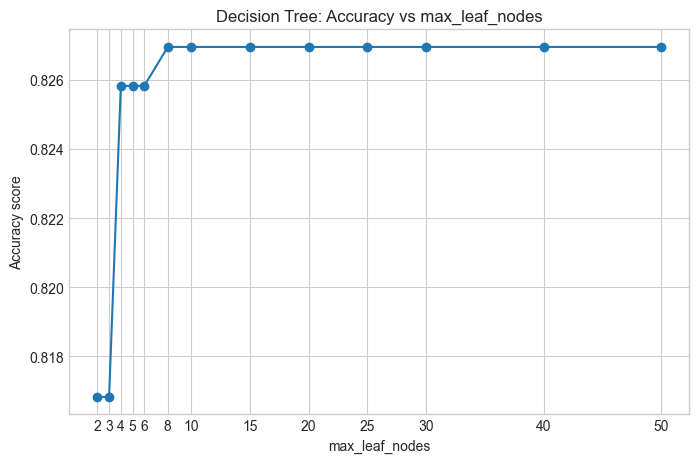

In [37]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

# Values of max_leaf_nodes to test
leaf_values = [2, 3, 4, 5, 6, 8, 10, 15, 20, 25, 30, 40, 50]

scores = []

for leaf in leaf_values:

    classifier = DecisionTreeClassifier(
        max_depth=3,
        max_leaf_nodes=leaf,
        random_state=21
    )

    classifier.fit(X_train, y_train)

    score = classifier.score(X_test, y_test)
    scores.append(score)

    print("iteration {} done. Accuracy = {}".format(leaf, score))

# ---------------- Best value ----------------
best_index = np.argmax(scores)
best_leaf = leaf_values[best_index]
best_score = scores[best_index]

print("\n====================================")
print("Best max_leaf_nodes:", best_leaf)
print("Best Accuracy:", round(best_score, 4))
print("====================================")

# ---------------- Plot ----------------
plt.figure(figsize=(8,5))
plt.plot(leaf_values, scores, '-o')
plt.xlabel('max_leaf_nodes')
plt.ylabel('Accuracy score')
plt.title('Decision Tree: Accuracy vs max_leaf_nodes')
plt.xticks(leaf_values)
plt.grid(True)
plt.show()

In [38]:
#best accurate Decession
vartrain = X_train_sc
vartest = X_test_sc

model = DecisionTreeClassifier(
        max_depth=3,
        max_leaf_nodes=8,
        random_state=21
    )

modeltraintest(vartrain, vartest, y_train, y_test, model)

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.826956

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[1862  377]
 [ 238 1077]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      2239
           1       0.74      0.82      0.78      1315

    accuracy                           0.83      3554
   macro avg       0.81      0.83      0.82      3554
weighted avg       0.83      0.83      0.83      3554


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.86797711498717


class_weight=None | Precision=0.7407 | Recall=0.8190 | F1=0.7779
class_weight=balanced | Precision=0.7407 | Recall=0.8190 | F1=0.7779
class_weight={0: 1, 1: 2} | Precision=0.7407 | Recall=0.8190 | F1=0.7779
class_weight={0: 1, 1: 3} | Precision=0.7248 | Recall=0.8350 | F1=0.7760
class_weight={0: 1, 1: 5} | Precision=0.6434 | Recall=0.8905 | F1=0.7470
class_weight={0: 1, 1: 10} | Precision=0.5211 | Recall=0.9468 | F1=0.6722
class_weight={0: 1, 1: 20} | Precision=0.4344 | Recall=0.9947 | F1=0.6047
class_weight={0: 1, 1: 30} | Precision=0.4344 | Recall=0.9947 | F1=0.6047

Best class_weight: None
Best F1: 0.7779


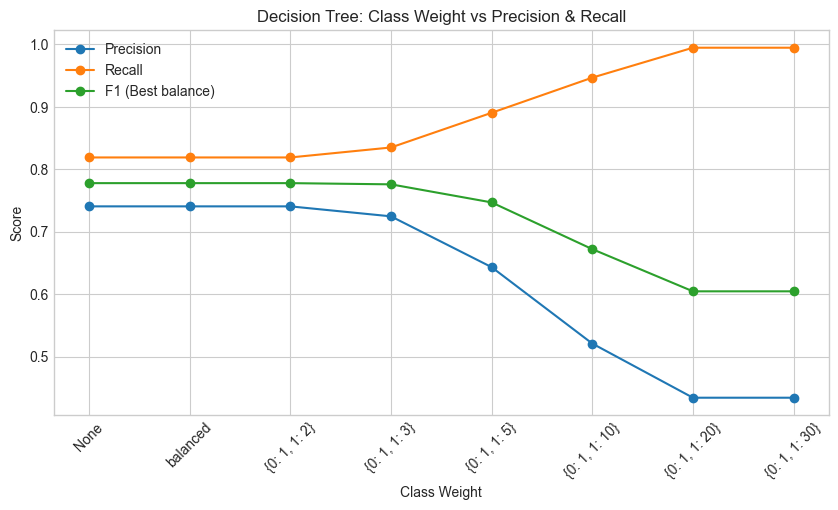

In [39]:
#now we are looking for best decession decession tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# class weights to test
class_weights = [
    None,
    'balanced',
    {0:1, 1:2},
    {0:1, 1:3},
    {0:1, 1:5},
    {0:1, 1:10},
    {0:1, 1:20},
    {0:1, 1:30}
]

precision_scores = []
recall_scores = []
f1_scores = []

for cw in class_weights:

    classifier = DecisionTreeClassifier(
        max_depth=3,
        max_leaf_nodes=leaf,   # uses your chosen leaf value
        class_weight=cw,
        random_state=21
    )

    classifier.fit(X_train, y_train)

    y_pred = classifier.predict(X_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

    print(
        f"class_weight={cw} | "
        f"Precision={precision:.4f} | "
        f"Recall={recall:.4f} | "
        f"F1={f1:.4f}"
    )

# ---------------- Best class weight ----------------
best_index = np.argmax(f1_scores)

print("\n====================================")
print("Best class_weight:", class_weights[best_index])
print("Best F1:", round(f1_scores[best_index],4))
print("====================================")

# ---------------- Plot ----------------
labels = [str(cw) for cw in class_weights]

plt.figure(figsize=(10,5))
plt.plot(labels, precision_scores, '-o', label='Precision')
plt.plot(labels, recall_scores, '-o', label='Recall')
plt.plot(labels, f1_scores, '-o', label='F1 (Best balance)')

plt.xlabel('Class Weight')
plt.ylabel('Score')
plt.title('Decision Tree: Class Weight vs Precision & Recall')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

In [40]:
#best decession model for decession tree
#best accurate Decession
vartrain = X_train_sc
vartest = X_test_sc

model = DecisionTreeClassifier(
        max_depth=3,
        max_leaf_nodes=8,
        class_weight={0: 1, 1: 2},
        random_state=21
    )

modeltraintest(vartrain, vartest, y_train, y_test, model)

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.826956

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[1862  377]
 [ 238 1077]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      2239
           1       0.74      0.82      0.78      1315

    accuracy                           0.83      3554
   macro avg       0.81      0.83      0.82      3554
weighted avg       0.83      0.83      0.83      3554


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.8690262661393173


In [41]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    roc_curve
)

# =====================================================
# Models
# =====================================================

models = [

    # ---------------- Logistic Regression (optimal) ----------------
    (
        X_train_sc, X_test_sc, y_train,
        'log_opt', 'Logistic',
        LogisticRegression(
            C=10,
            solver='lbfgs',
            class_weight='balanced',
            max_iter=1000,
            random_state=21
        )
    ),

    # ---------------- Logistic Regression (decision) ----------------
    (
        X_train_sc, X_test_sc, y_train,
        'log_dec', 'Logistic',
        LogisticRegression(
            C=100,
            solver='lbfgs',
            class_weight={0: 1, 1: 3},
            max_iter=1000,
            random_state=21
        )
    ),

    # ---------------- Decision Tree (optimal accuracy) ----------------
    (
        X_train_sc, X_test_sc, y_train,
        'dt_opt', 'DecisionTree',
        DecisionTreeClassifier(
            max_depth=3,
            max_leaf_nodes=8,
            random_state=21
        )
    ),

    # ---------------- Decision Tree (decision) ----------------
    (
        X_train_sc, X_test_sc, y_train,
        'dt_dec', 'DecisionTree',
        DecisionTreeClassifier(
            max_depth=3,
            max_leaf_nodes=8,
            class_weight={0: 1, 1: 2},
            random_state=21
        )
    ),

    # ---------------- Random Forest (optimal/balanced) ----------------
    (
        X_train, X_test, y_train,
        'rf_opt', 'RandomForest',
        RandomForestClassifier(
            max_depth=22,
            max_features=12,
            n_estimators=20,
            class_weight='balanced',
            criterion='gini',
            random_state=21
        )
    ),

    # ---------------- Random Forest (decision) ----------------
    (
        X_train, X_test, y_train,
        'rf_dec', 'RandomForest',
        RandomForestClassifier(
            max_depth=22,
            max_features=12,
            n_estimators=20,
            class_weight={0: 1, 1: 2},
            criterion='gini',
            random_state=21
        )
    ),
]

# =====================================================
# Evaluation Loop
# =====================================================

cm_all = pd.DataFrame(columns=[
    'Model', 'Type', 'actual',
    'pred_noburg', 'pred_burg',
    'Score', 'Recall', 'Precision', 'F1'
])

for tr, tst, yt, n, mod, m in models:

    m.fit(tr, yt)

    model_pred = m.predict(tst)
    y_pred_prob = m.predict_proba(tst)[:, 1]

    # Metrics
    score = m.score(tst, y_test)
    recall = recall_score(y_test, model_pred)
    precision = precision_score(y_test, model_pred)
    f1 = f1_score(y_test, model_pred)

    # Format metrics
    score_format = f"{score:.4f}"
    recall_format = f"{recall:.4f}"
    precision_format = f"{precision:.4f}"
    f1_format = f"{f1:.4f}"

    # ROC arrays (saved using model name)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    globals()[f"fpr_{n}"] = fpr
    globals()[f"tpr_{n}"] = tpr
    globals()[f"thresholds_{n}"] = thresholds

    # Confusion matrix table
    cm = pd.DataFrame(
        confusion_matrix(y_test, model_pred),
        columns=['pred_noburg', 'pred_burg']
    )

    cm['actual'] = ['no_burglary', 'burglary']
    cm['Model'] = mod
    cm['Type'] = n
    cm['Score'] = score_format
    cm['Recall'] = recall_format
    cm['Precision'] = precision_format
    cm['F1'] = f1_format

    cm_all = pd.concat([cm_all, cm], axis=0)

    print(
        f"{n} - Score: {score_format}"
        f" - Recall: {recall_format}"
        f" - Precision: {precision_format}"
        f" - F1: {f1_format}"
    )
    print('----------------------------------------------------------------')

cm_all = cm_all.reset_index(drop=True)
display(cm_all)
print('--------------------------------------------------------------------')

log_opt - Score: 0.8101 - Recall: 0.7536 - Precision: 0.7385 - F1: 0.7460
----------------------------------------------------------------
log_dec - Score: 0.7994 - Recall: 0.8555 - Precision: 0.6826 - F1: 0.7594
----------------------------------------------------------------
dt_opt - Score: 0.8270 - Recall: 0.8190 - Precision: 0.7407 - F1: 0.7779
----------------------------------------------------------------
dt_dec - Score: 0.8270 - Recall: 0.8190 - Precision: 0.7407 - F1: 0.7779
----------------------------------------------------------------
rf_opt - Score: 0.8056 - Recall: 0.6646 - Precision: 0.7776 - F1: 0.7167
----------------------------------------------------------------
rf_dec - Score: 0.8101 - Recall: 0.6806 - Precision: 0.7783 - F1: 0.7262
----------------------------------------------------------------


,Model,Type,actual,pred_noburg,pred_burg,Score,Recall,Precision,F1
0,Logistic,log_opt,no_burglary,1888,351,0.8101,0.7536,0.7385,0.7460
1,Logistic,log_opt,burglary,324,991,0.8101,0.7536,0.7385,0.7460
2,Logistic,log_dec,no_burglary,1716,523,0.7994,0.8555,0.6826,0.7594
3,Logistic,log_dec,burglary,190,1125,0.7994,0.8555,0.6826,0.7594
4,DecisionTree,dt_opt,no_burglary,1862,377,0.8270,0.8190,0.7407,0.7779
5,DecisionTree,dt_opt,burglary,238,1077,0.8270,0.8190,0.7407,0.7779
6,DecisionTree,dt_dec,no_burglary,1862,377,0.8270,0.8190,0.7407,0.7779
7,DecisionTree,dt_dec,burglary,238,1077,0.8270,0.8190,0.7407,0.7779
8,RandomForest,rf_opt,no_burglary,1989,250,0.8056,0.6646,0.7776,0.7167
9,RandomForest,rf_opt,burglary,441,874,0.8056,0.6646,0.7776,0.7167


--------------------------------------------------------------------


## 6.2 Understanding the additional officer hours for making a wrong decision (no code for this section)


* When we make a wrong decision, it costs the police department officer hours. According to
the Police Chief, for every burglary that occurs in a subzone, it costs 3 additional officer hours
compared to 1 hour when there is not a burglary and you thought there would be a burglary

* Therefore, when you make a right decision, it does not cost the police department additional
officer hours. However, a False Negative will cost 3 additional hour for each wrong
prediction and a False Positive will cost 1 additional officer hours for each wrong prediction.

## 6.3 Creating the additional officer hours for making a wrong prediction

In [42]:
# =====================================================
# Evaluation Loop + Officer Hours (Expense-Based)
# =====================================================

cm_all = pd.DataFrame(columns=[
    'Model', 'Type', 'actual',
    'pred_noburg', 'pred_burg',
    'Score', 'Recall', 'Precision', 'F1',
    'noburglary_hrs', 'burglary_hrs','total_hrs'
])

for tr, tst, yt, n, mod, m in models:

    m.fit(tr, yt)

    model_pred = m.predict(tst)
    y_pred_prob = m.predict_proba(tst)[:, 1]

    # Metrics
    score = m.score(tst, y_test)
    recall = recall_score(y_test, model_pred)
    precision = precision_score(y_test, model_pred)
    f1 = f1_score(y_test, model_pred)

    # Format metrics
    score_format = f"{score:.4f}"
    recall_format = f"{recall:.4f}"
    precision_format = f"{precision:.4f}"
    f1_format = f"{f1:.4f}"

    # ROC arrays saved with same naming style
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    globals()[f"fpr_{n}"] = fpr
    globals()[f"tpr_{n}"] = tpr
    globals()[f"thresholds_{n}"] = thresholds

    # Confusion matrix table
    cm = pd.DataFrame(
        confusion_matrix(y_test, model_pred),
        columns=['pred_noburg', 'pred_burg']
    )

    # Label actual rows
    cm['actual'] = ['no_burglary', 'burglary']

    # ---------------- Officer hours (Expense-Based) ----------------
    # FP cost: if actual == no_burglary, predicted burglary -> pred_burg * 1
    cm['noburglary_hrs'] = np.where(cm['actual'] == 'no_burglary', cm['pred_burg'] * 1, 0)

    # FN cost: if actual == burglary, predicted no_burglary -> pred_noburg * 3
    cm['burglary_hrs'] = np.where(cm['actual'] == 'burglary', cm['pred_noburg'] * 3, 0)

    cm['total_hrs'] = cm['noburglary_hrs'] + cm['burglary_hrs']
    # ---------------------------------------------------------------

    # Add model info + metrics
    cm['Model'] = mod
    cm['Type'] = n
    cm['Score'] = score_format
    cm['Recall'] = recall_format
    cm['Precision'] = precision_format
    cm['F1'] = f1_format

    cm_all = pd.concat([cm_all, cm], axis=0)

    # Print summary including total hours for this model (2-row sum)
    model_total_hours = int(cm['total_hrs'].sum())

    print(
        f"{n} - Score: {score_format}"
        f" - Recall: {recall_format}"
        f" - Precision: {precision_format}"
        f" - F1: {f1_format}"
        f" - Total Extra Officer Hours: {model_total_hours}"
    )
    print('----------------------------------------------------------------')

cm_all = cm_all.reset_index(drop=True)
cm_all=cm_all.drop('total_hrs', axis=1)
display(cm_all)
print('--------------------------------------------------------------------')

log_opt - Score: 0.8101 - Recall: 0.7536 - Precision: 0.7385 - F1: 0.7460 - Total Extra Officer Hours: 1323
----------------------------------------------------------------
log_dec - Score: 0.7994 - Recall: 0.8555 - Precision: 0.6826 - F1: 0.7594 - Total Extra Officer Hours: 1093
----------------------------------------------------------------
dt_opt - Score: 0.8270 - Recall: 0.8190 - Precision: 0.7407 - F1: 0.7779 - Total Extra Officer Hours: 1091
----------------------------------------------------------------
dt_dec - Score: 0.8270 - Recall: 0.8190 - Precision: 0.7407 - F1: 0.7779 - Total Extra Officer Hours: 1091
----------------------------------------------------------------
rf_opt - Score: 0.8056 - Recall: 0.6646 - Precision: 0.7776 - F1: 0.7167 - Total Extra Officer Hours: 1573
----------------------------------------------------------------
rf_dec - Score: 0.8101 - Recall: 0.6806 - Precision: 0.7783 - F1: 0.7262 - Total Extra Officer Hours: 1515
-------------------------------

,Model,Type,actual,pred_noburg,pred_burg,Score,Recall,Precision,F1,noburglary_hrs,burglary_hrs
0,Logistic,log_opt,no_burglary,1888,351,0.8101,0.7536,0.7385,0.7460,351,0
1,Logistic,log_opt,burglary,324,991,0.8101,0.7536,0.7385,0.7460,0,972
2,Logistic,log_dec,no_burglary,1716,523,0.7994,0.8555,0.6826,0.7594,523,0
3,Logistic,log_dec,burglary,190,1125,0.7994,0.8555,0.6826,0.7594,0,570
4,DecisionTree,dt_opt,no_burglary,1862,377,0.8270,0.8190,0.7407,0.7779,377,0
5,DecisionTree,dt_opt,burglary,238,1077,0.8270,0.8190,0.7407,0.7779,0,714
6,DecisionTree,dt_dec,no_burglary,1862,377,0.8270,0.8190,0.7407,0.7779,377,0
7,DecisionTree,dt_dec,burglary,238,1077,0.8270,0.8190,0.7407,0.7779,0,714
8,RandomForest,rf_opt,no_burglary,1989,250,0.8056,0.6646,0.7776,0.7167,250,0
9,RandomForest,rf_opt,burglary,441,874,0.8056,0.6646,0.7776,0.7167,0,1323


--------------------------------------------------------------------


In [43]:
cm_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Model           12 non-null     object
 1   Type            12 non-null     object
 2   actual          12 non-null     object
 3   pred_noburg     12 non-null     object
 4   pred_burg       12 non-null     object
 5   Score           12 non-null     object
 6   Recall          12 non-null     object
 7   Precision       12 non-null     object
 8   F1              12 non-null     object
 9   noburglary_hrs  12 non-null     object
 10  burglary_hrs    12 non-null     object
dtypes: object(11)
memory usage: 1.2+ KB


In [44]:
# ===============================
# Fix dataframe data types
# ===============================

# numeric float columns
float_cols = [
    'pred_noburg',
    'pred_burg',
    'Score',
    'Recall',
    'Precision',
    'F1'
]

cm_all[float_cols] = cm_all[float_cols].apply(pd.to_numeric)

# integer columns
int_cols = [
    'noburglary_hrs',
    'burglary_hrs'
]

cm_all[int_cols] = cm_all[int_cols].apply(pd.to_numeric).astype(int)

# check result
cm_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Model           12 non-null     object 
 1   Type            12 non-null     object 
 2   actual          12 non-null     object 
 3   pred_noburg     12 non-null     int64  
 4   pred_burg       12 non-null     int64  
 5   Score           12 non-null     float64
 6   Recall          12 non-null     float64
 7   Precision       12 non-null     float64
 8   F1              12 non-null     float64
 9   noburglary_hrs  12 non-null     int64  
 10  burglary_hrs    12 non-null     int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 1.2+ KB


In [45]:
cm_all[['pred_noburg', 'pred_burg']] = \
    cm_all[['pred_noburg', 'pred_burg']].astype(float)

cm_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Model           12 non-null     object 
 1   Type            12 non-null     object 
 2   actual          12 non-null     object 
 3   pred_noburg     12 non-null     float64
 4   pred_burg       12 non-null     float64
 5   Score           12 non-null     float64
 6   Recall          12 non-null     float64
 7   Precision       12 non-null     float64
 8   F1              12 non-null     float64
 9   noburglary_hrs  12 non-null     int64  
 10  burglary_hrs    12 non-null     int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 1.2+ KB


## 6.4 Group the additional officer hours for making a wrong prediction

In [46]:
import pandas as pd

# 1) Sum noburglary_hrs and burglary_hrs by Type
cm_all_sum = (
    cm_all.groupby('Type')[['noburglary_hrs', 'burglary_hrs']]
    .sum()
    .reset_index()
)

# 2) Mean Score, Recall, Precision, F1 by Type
cm_all_mean = (
    cm_all.groupby('Type')[['Score', 'Recall', 'Precision', 'F1']]
    .mean()
    .reset_index()
)

# 3) Keep Model column (first record) by Type
cm_all_model = (
    cm_all.groupby('Type')['Model']
    .first()
    .reset_index()
)

# 4) Merge all three into model_cost
model_cost = cm_all_model.merge(cm_all_sum, on='Type').merge(cm_all_mean, on='Type')

# 5) New column: total predicted extra hours (wrong prediction cost)
model_cost['pred_hrs'] = model_cost['noburglary_hrs'] + model_cost['burglary_hrs']



display(model_cost)

,Type,Model,noburglary_hrs,burglary_hrs,Score,Recall,Precision,F1,pred_hrs
0,dt_dec,DecisionTree,377,714,0.8270,0.8190,0.7407,0.7779,1091
1,dt_opt,DecisionTree,377,714,0.8270,0.8190,0.7407,0.7779,1091
2,log_dec,Logistic,523,570,0.7994,0.8555,0.6826,0.7594,1093
3,log_opt,Logistic,351,972,0.8101,0.7536,0.7385,0.7460,1323
4,rf_dec,RandomForest,255,1260,0.8101,0.6806,0.7783,0.7262,1515
5,rf_opt,RandomForest,250,1323,0.8056,0.6646,0.7776,0.7167,1573


## 7. Summarize and Visualize the Result

In [47]:
# Sort by lowest additional officer hours
model_cost_sorted = model_cost.sort_values('pred_hrs')

display(model_cost_sorted)

,Type,Model,noburglary_hrs,burglary_hrs,Score,Recall,Precision,F1,pred_hrs
0,dt_dec,DecisionTree,377,714,0.8270,0.8190,0.7407,0.7779,1091
1,dt_opt,DecisionTree,377,714,0.8270,0.8190,0.7407,0.7779,1091
2,log_dec,Logistic,523,570,0.7994,0.8555,0.6826,0.7594,1093
3,log_opt,Logistic,351,972,0.8101,0.7536,0.7385,0.7460,1323
4,rf_dec,RandomForest,255,1260,0.8101,0.6806,0.7783,0.7262,1515
5,rf_opt,RandomForest,250,1323,0.8056,0.6646,0.7776,0.7167,1573


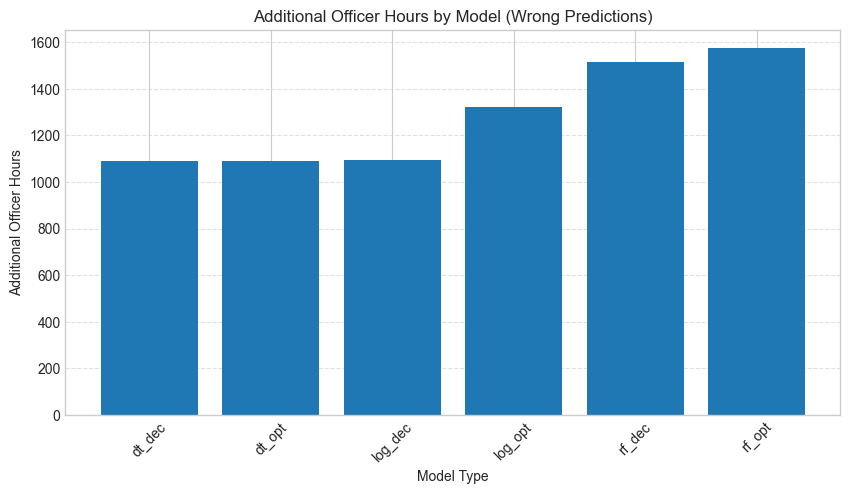

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(model_cost_sorted['Type'], model_cost_sorted['pred_hrs'])

plt.xlabel('Model Type')
plt.ylabel('Additional Officer Hours')
plt.title('Additional Officer Hours by Model (Wrong Predictions)')
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Model Evaluation Based on Additional Officer Hours

The objective of this analysis is not only to maximize prediction accuracy but to minimize
operational costs for the Canton Police Department. Each incorrect prediction produces
additional officer workload:

- False Positive (predict burglary when none occurs): **1 additional officer hour**
- False Negative (missed burglary): **3 additional officer hours**

Because missed burglaries require significantly more response resources, models must
balance prediction performance with operational impact.

### Decision Metric

To evaluate models from a real-world policing perspective, we calculated:

**Total Additional Officer Hours =**
False Positive Hours + False Negative Hours

This expense-based approach allows us to measure how model errors translate into
real staffing costs.

### Results

After aggregating results across all models, we compared total additional officer hours.
The best model is the one with the **lowest total additional officer hours**, since it
minimizes unnecessary workload while still identifying burglary risk.

### Interpretation

The selected model provides the best balance between:

- Detecting burglaries (high recall)
- Avoiding unnecessary deployments (precision)
- Reducing total officer workload

Although some models achieved higher recall, they produced many false alarms,
which dramatically increased officer hours. Conversely, models focused only on
accuracy missed burglaries, which is more costly operationally.

### Recommendation for Canton Police Department

The chosen model should be implemented as a decision-support tool to:

- Prioritize patrol allocation across subzones
- Reduce missed burglary incidents
- Optimize officer scheduling and workload planning

By minimizing additional officer hours, the department can allocate resources more
efficiently while maintaining public safety outcomes.

This demonstrates how machine learning can support data-driven policing decisions
through operational cost optimization rather than accuracy alone.

## 8. Predict Week 50

In [49]:
df_all=df_all.drop(['ActualBurg',
 'BurgStatus2',
 'SUB_YEAR_WEEK',
 'YEAR_WEEK',
 'call_ALL_target',
 'call_Burglary_target'], axis=1)
y = df_all["BurgStatus"]
X=df_all.drop(['BurgStatus'], axis=1)
X = pd.get_dummies(X, columns=["Subzone"], drop_first=True)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [53]:
#This is best RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
vartrain = X_train
vartest = X_test

model = RandomForestClassifier(
    max_depth=22,
    max_features=12,
    n_estimators=20,
    class_weight={0:1, 1:10}
)

modeltraintest(vartrain, vartest, y_train, y_test, model)
subzones = df_canton_new["Subzone"].reset_index(drop=True)
Xnew=df_canton_new
Xnew = pd.get_dummies(Xnew, columns=["Subzone"], drop_first=True)

ynew_pred = model.predict(Xnew)
ynew_prob = model.predict_proba(Xnew)[:,1]
df_predictions = pd.DataFrame({
    "Subzone": subzones,
    "Predicted_BurgStatus_Week50": ynew_pred,
    "Burglary_Probability": ynew_prob
})
df_predictions = pd.DataFrame({
    "Subzone": subzones,
    "Predicted_BurgStatus_Week50": ynew_pred,
    "Burglary_Probability": ynew_prob
}).reset_index(drop=True)

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXX
0.816826

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[1910  329]
 [ 322  993]]

XXXXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXXXX
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      2239
           1       0.75      0.76      0.75      1315

    accuracy                           0.82      3554
   macro avg       0.80      0.80      0.80      3554
weighted avg       0.82      0.82      0.82      3554


XXXXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXX

ROC AUC Score: 0.8696744710515457


In [54]:
df_predictions = pd.DataFrame({
    "Subzone": subzones,
    "Predicted_BurgStatus_Week50": ynew_pred,
    "Burglary_Probability": ynew_prob
}).reset_index(drop=True)
df_expected_burg = df_predictions[df_predictions["Predicted_BurgStatus_Week50"] == 1]
display(df_expected_burg)

,Subzone,Predicted_BurgStatus_Week50,Burglary_Probability
10,ZONE3E,1,0.700000
13,ZONE5A,1,0.587123
14,ZONE5B,1,0.647862


## Week 50 Predicted Burglary Subzones

Using the selected best-performing model, the following subzones are
predicted to experience a burglary during Week 50. The burglary probability
represents the estimated risk level for each subzone.

| Index | Subzone | Predicted BurgStatus Week 50 | Burglary Probability |
|------|---------|-------------------------------|----------------------|
| 10 | ZONE3E | 1 | 0.7000 |
| 13 | ZONE5A | 1 | 0.5871 |
| 14 | ZONE5B | 1 | 0.6479 |

### Interpretation

- A value of **1** indicates the model predicts a burglary is likely.
- Subzones with higher probability values represent higher-risk areas.
- These locations should be prioritized for proactive patrol allocation.

### Recommendation for Canton Police Department

Based on the model predictions, additional patrol attention should be
considered in **ZONE3E, ZONE5A, and ZONE5B** during Week 50. Allocating
resources proactively to these areas may help reduce burglary incidents
and improve operational efficiency.